# Trabalho 6

In [36]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [37]:
import sys
import os
import matplotlib.pyplot as plt
import numpy as np

from IPython.display import Image
from matplotlib.animation import FuncAnimation

# local imports
sys.path.append(os.path.abspath(r"../util/"))


from geometry import Pose, Angle
from robot import Robot
from maps import LandmarkMap, Landmark
from control import VelocityControl, generateConstantVelocityTrajectory
from ekf import EKFSlamKnownCorrespondences
from camera import Camera, DetectedFeature
from motion_models import CircularMotion

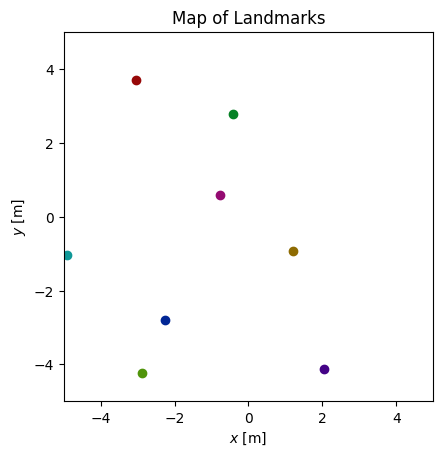

In [38]:
# create map
n_landmarks = 8

x_lims = (-5, 5)
y_lims = (-5, 5)

landmarks = []
for signature in range(n_landmarks):
    #sample coordinates in roi
    x = np.random.uniform(x_lims[0], x_lims[1])
    y = np.random.uniform(y_lims[0], y_lims[1])
    phi = Angle(np.random.uniform(0, 2 * np.pi))
    #create landmark
    landmarks.append(Landmark(Pose(x, y, phi), signature))

env = LandmarkMap(landmarks, x_lims=x_lims, y_lims=y_lims)

#plot map
f, ax = plt.subplots()

ax.set_title("Map of Landmarks")
ax.set_xlabel("$x$ [m]")
ax.set_ylabel("$y$ [m]")
ax.set_aspect('equal', adjustable='box')

env.draw(ax)

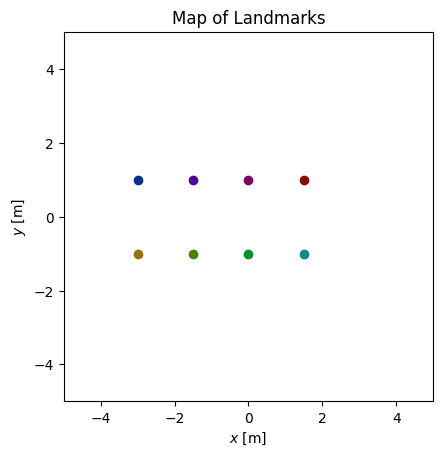

In [39]:
# create map
n_landmarks = 8

x_lims = (-5, 5)
y_lims = (-5, 5)

landmarks = [
    Landmark(Pose(-3.0, -1, Angle(0)), 0),
    Landmark(Pose(-1.5, -1, Angle(0)), 1),
    Landmark(Pose( 0.0, -1, Angle(0)), 2),
    Landmark(Pose( 1.5, -1, Angle(0)), 3),
    Landmark(Pose(-3.0,  1, Angle(0)), 4),
    Landmark(Pose(-1.5,  1, Angle(0)), 5),
    Landmark(Pose( 0.0,  1, Angle(0)), 6),
    Landmark(Pose( 1.5,  1, Angle(0)), 7),
]

env = LandmarkMap(landmarks, x_lims=x_lims, y_lims=y_lims)

#plot map
f, ax = plt.subplots()

ax.set_title("Map of Landmarks")
ax.set_xlabel("$x$ [m]")
ax.set_ylabel("$y$ [m]")
ax.set_aspect('equal', adjustable='box')

env.draw(ax)

In [40]:
#set initial position
x0 = Pose(0, 0, Angle.from_deg(0))

#set dt for simulation
dt = 0.05 #[s]

In [41]:
#set initial position
x0 = Pose(-4.4, 1, Angle.from_deg(0))

#set dt for simulation
dt = 0.05 #[s]

In [42]:
fov = Angle.from_deg(80) #[°]
sensor_range = 5 #[m]

#define robot's sensor
camera = Camera(Pose(0, 0., Angle.from_deg(0)), field_of_veiw=fov, sensor_range=sensor_range, robot_pose=x0)

In [43]:
fov = Angle.from_deg(20) #[°]
sensor_range = 1.2 #[m]

#define robot's sensor
camera = Camera(Pose(0.5, 0., Angle.from_deg(0)), field_of_veiw=fov, sensor_range=sensor_range, robot_pose=x0)

In [44]:
#define the robot
robot = Robot(
    x0, 
    sensors = [
        camera
    ],
)

In [45]:
ekf = EKFSlamKnownCorrespondences(n_landmarks)
print(ekf.sigma)

[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.

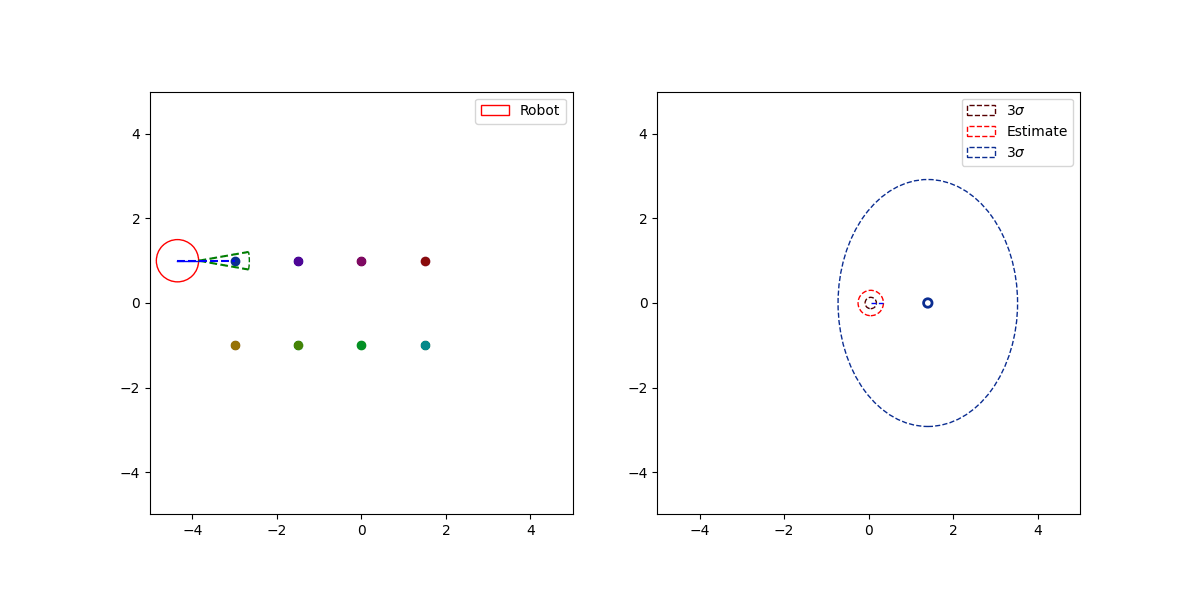

In [ ]:

animation_time = 5 #[s]
measurement_frequency = 1#1 / 3 #[Hz]

n_frames = int(animation_time / dt)
trajectory = generateConstantVelocityTrajectory(n_frames, 0.5, -np.pi / 5, dt)
trajectory_a = generateConstantVelocityTrajectory(int(5 / dt), 0.5, 0., dt)
trajectory_b = generateConstantVelocityTrajectory(int(5 / dt), 0.5, -np.pi / 5, dt)
trajectory_c = generateConstantVelocityTrajectory(int(5 / dt), 0.5, 0., dt)
trajectory_d = generateConstantVelocityTrajectory(int(5 / dt), 0.5, -np.pi / 5, dt)
trajectory_e = generateConstantVelocityTrajectory(int(5 / dt), 0.5, 0., dt)
trajectory = [*trajectory_a, *trajectory_b, *trajectory_c, *trajectory_d, *trajectory_e]
n_frames = len(trajectory)
animation_time = n_frames * dt
applied_controls = []

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

env.draw(ax1)
ax1.set_aspect('equal', adjustable='box')
ax1.set_title("Robot with Measurements w.r.t. the Groundtruth")
ax1.set_xlabel("$x$ [m]")
ax1.set_ylabel("$y$ [m]")

ax2.set_title("Occupancy Grid")
ax2.set_xlabel("$x$ [m]")
ax2.set_ylabel("$y$ [m]")
#update function for animation
sampling_intervall = 1 / measurement_frequency #[s]
time_since_last_measurement = 0 #[s]
last_position_estimate = x0
def update(frame):
    global applied_controls, sampling_intervall, time_since_last_measurement
    ax2.clear()
    ax1.clear()
    
    u = trajectory[frame]
    u_eff = robot.applyControl(u)
    applied_controls.append(u_eff)

#    if time_since_last_measurement >= sampling_intervall:
#        time_since_last_measurement = 0
#        robot.measure(env,detection_noise=False)
#    else:
#        time_since_last_measurement += dt

    robot.measure(env,detection_noise=False)
    detected_features = robot.getCurrentSensorReadings()[0]
    ekf.update(u_eff, detected_features if detected_features is None else detected_features['features'])
    env.draw(ax1)
    robot.draw(ax1, r = 0.5, draw_sensors=True)
    ekf.draw(ax2, env.colors)
    #env.draw(ax2)
    ax2.set_xlim(x_lims[0], x_lims[1])
    ax2.set_ylim(y_lims[0], y_lims[1])  
    ax2.set_aspect('equal', adjustable='box')
    print(f"Progress: {((frame / (n_frames - 1)) * 100):.2f}", end="\r")     

ani = FuncAnimation(fig, update, frames=np.arange(0, n_frames), interval=dt * 1000)

gif_path = 'img/sim0.gif'
ani.save(gif_path, writer='pillow', fps=20)

plt.close(fig)

display(Image(filename=gif_path))

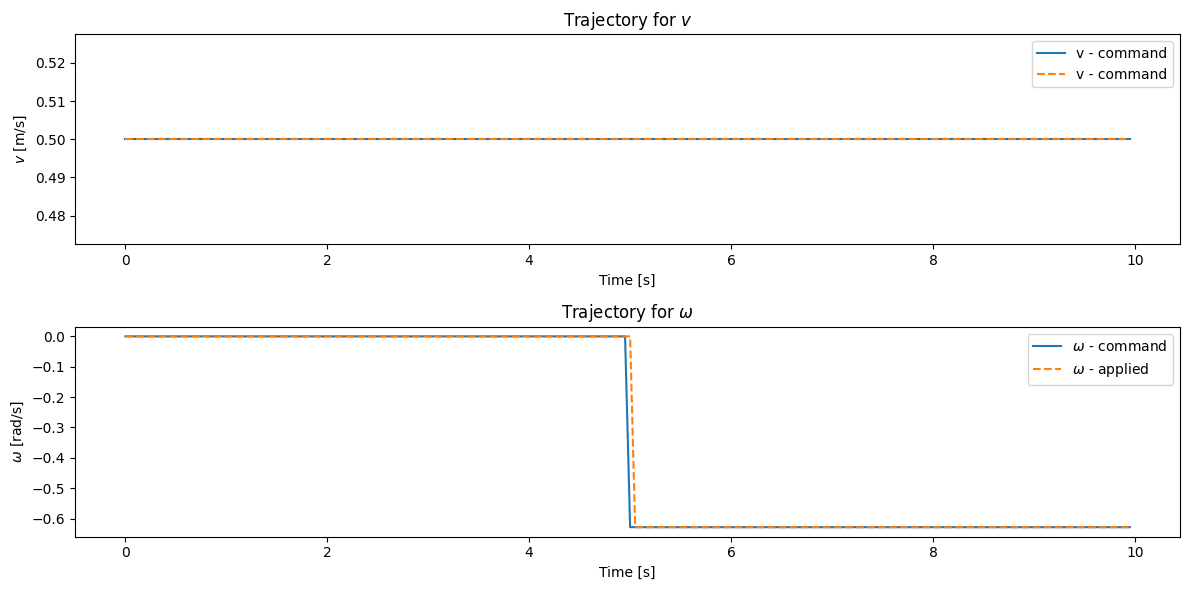

In [47]:
v_traj= []
w_traj = []
v_eff_traj = []
w_eff_traj = []
t_traj = []

t = 0
for u, u_eff in zip(trajectory, applied_controls):
    t_traj.append(t)
    v_traj.append(u.v)
    w_traj.append(u.w) 
    v_eff_traj.append(u_eff.v) 
    w_eff_traj.append(u_eff.w) 
    t += dt

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6))
ax1.set_title("Trajectory for $v$")
ax1.set_xlabel("Time [s]")
ax1.set_ylabel(r"$v$ [m/s]")

ax2.set_title("Trajectory for $\\omega$")
ax2.set_xlabel("Time [s]")
ax2.set_ylabel(r"$\omega$ [rad/s]")

ax1.plot(t_traj, v_traj, label="v - command")
ax1.plot(t_traj, v_eff_traj, linestyle='--', label="v - command")
ax1.legend()

ax2.plot(t_traj, w_traj, label="$\\omega$ - command")
ax2.plot(t_traj, w_eff_traj, linestyle='--', label="$\\omega$ - applied")
ax2.legend()
plt.tight_layout()